In [1]:
import pandas as pd
import numpy as np

In [2]:
low_mass_central_df = pd.read_parquet ('../low_mass_central_df_annuli_revised.parquet')

In [3]:
low_mass_central_df 

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00


In [4]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_central_df['SFE_local'] = 10**(low_mass_central_df['avg_SFR'] - low_mass_central_df['avg_gas_mass'])
# low_mass_central_df['f_gas_local'] = 10**(low_mass_central_df['avg_gas_mass'] - low_mass_central_df['avg_s_mass'])

# # drop rows where SFR and gas_mass are 0
# low_mass_central_df = low_mass_central_df[~((low_mass_central_df['global_SFRs'] == 0) & (low_mass_central_df['gas_mass'] == 0))]

# # creating copy to avoid set with copy warning
# low_mass_central_df = low_mass_central_df.copy()

# # if the gas mass is 0, set it to default value 10^-3.5
# mask = low_mass_central_df['gas_mass'] == 0.0
# low_mass_central_df.loc[mask, 'gas_mass'] = 10**(-3.5) * low_mass_central_df.loc[mask, 's_mass']


# low_mass_central_df['SFE_global'] = low_mass_central_df['global_SFRs']/low_mass_central_df['gas_mass']
# low_mass_central_df['f_gas_global'] = low_mass_central_df['gas_mass']/low_mass_central_df['s_mass']

In [5]:
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00


In [6]:
galaxy_class_counts = low_mass_central_df.groupby("subID")["quenching_vector"].nunique()

# count galaxies with only one class vs. two classes
num_single_class_galaxies = (galaxy_class_counts == 1).sum()
num_two_class_galaxies = (galaxy_class_counts > 1).sum()

print(f"Number of galaxies with only one class: {num_single_class_galaxies}")
print(f"Number of galaxies with two classes: {num_two_class_galaxies}")

Number of galaxies with only one class: 1473
Number of galaxies with two classes: 1233


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

low_mass_central_df = low_mass_central_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR", "avg_gas_mass","gas_mass", "Bfld", "veldisp", "BH_AGN"])
# low_mass_central_df = low_mass_central_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR", "avg_gas_mass","avg_s_mass", "BHMass", "BH_AGN", "bulge", "s_mass", "overdens", "bin_radii", "Mhalo", "gas_mass"])

low_mass_central_df.duplicated()

15916    False
15917    False
15918    False
15919    False
15920    False
         ...  
63077    False
63078    False
63079    False
63080    False
63081    False
Length: 21677, dtype: bool

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=600, min_samples_split=50, n_estimators=500; total time=   7.8s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=600, min_samples_split=50, n_estimators=500; total time=   7.8s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=600, min_samples_split=50, n_estimators=500; total time=   8.1s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=600, min_samples_split=50, n_estimators=500; total time=   8.3s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=400; total time=   6.1s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_

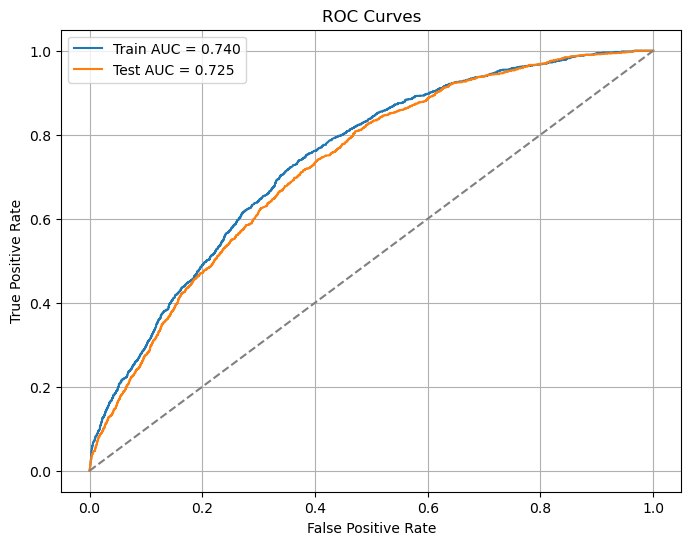

{'n_estimators': 300, 'min_samples_split': 150, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=200, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=200, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=200, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=200, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.9s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=600, min_samples_split=1

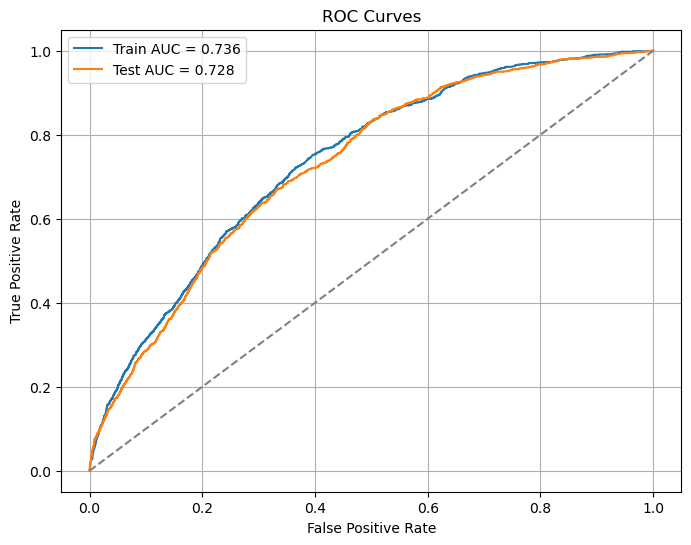

{'n_estimators': 300, 'min_samples_split': 150, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=300; total time=   4.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=300; total time=   4.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=300; total time=   4.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=300; total time=   4.6s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=1

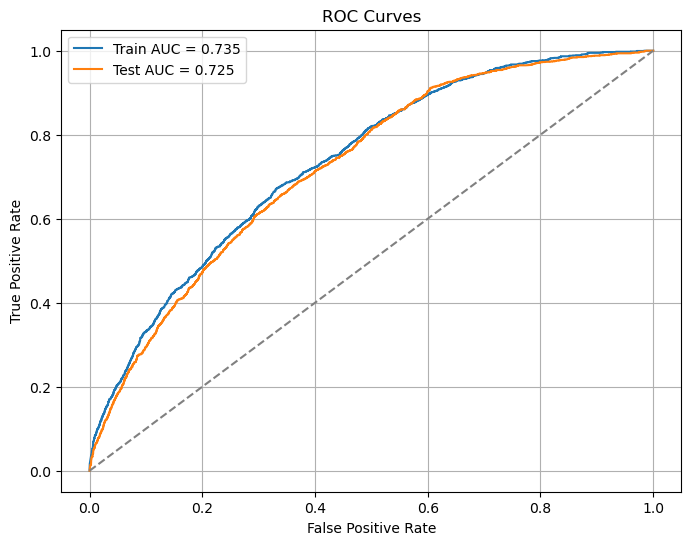

{'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=50, n_estimators=500; total time=   7.6s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=50, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=50, n_estimators=500; total time=   7.8s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=50, n_estimators=500; total time=   7.9s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=50, n_

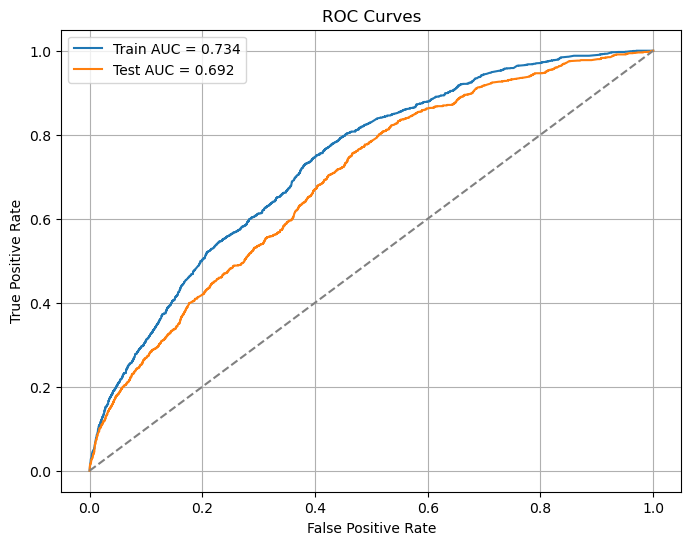

{'n_estimators': 400, 'min_samples_split': 150, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 100, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.3s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.4s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=50, n_

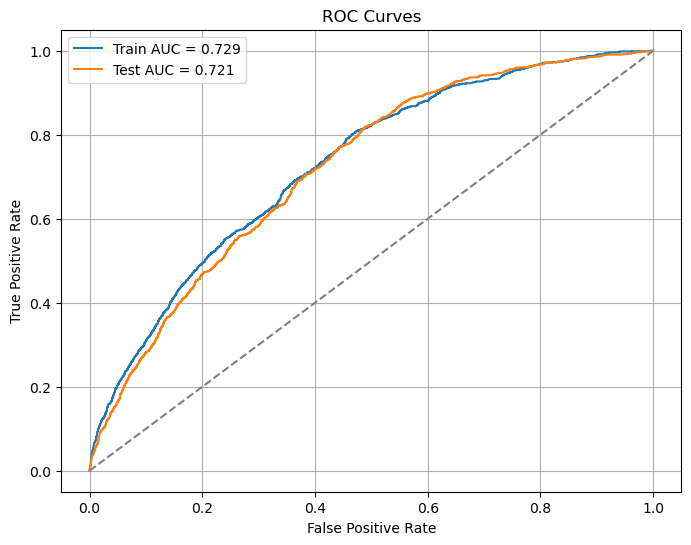

{'n_estimators': 400, 'min_samples_split': 100, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.3s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.6s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=600, min_samples_split=100, n_estimators=400; total time=   6.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=600, min_samples_split=1

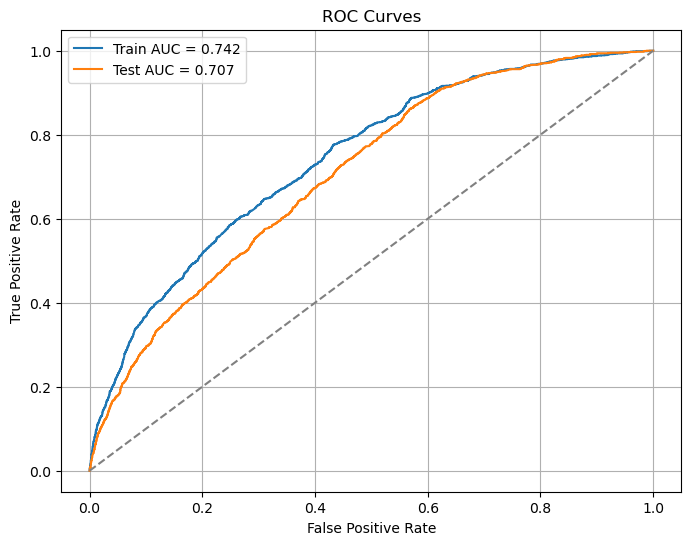

{'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.8s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.8s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.9s
[CV] END bootstrap=True, class_weight=balanced, max_depth=150, max_features=None, min_samples_leaf=700, min_samples_split=1

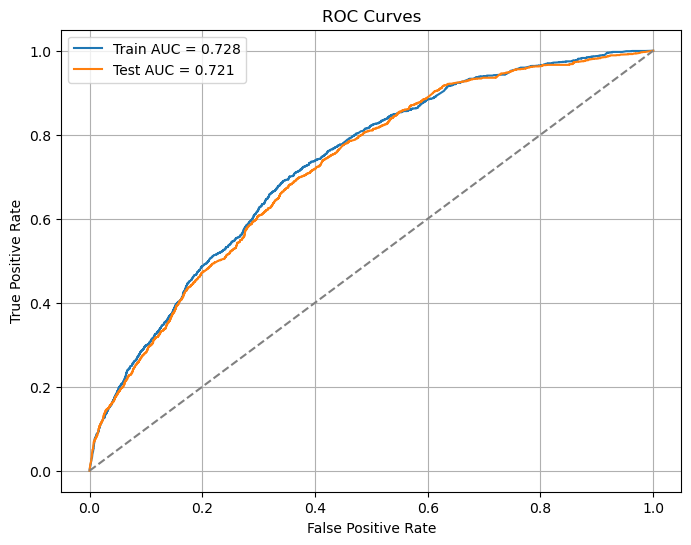

{'n_estimators': 400, 'min_samples_split': 100, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 200, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=400; total time=   5.9s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=400; total time=   6.1s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=400; total time=   6.1s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=400; total time=   6.2s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=None, min_samples_leaf=700, min_samples_split=100, n

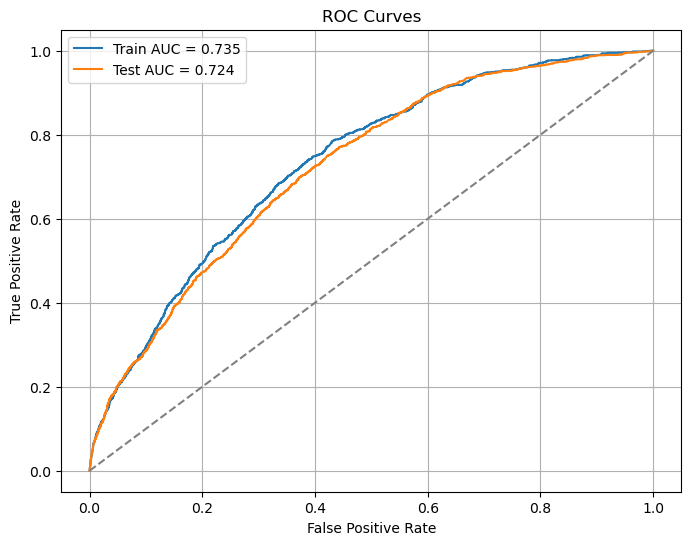

{'n_estimators': 300, 'min_samples_split': 50, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 100, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=100, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.2s
[CV] END bootstrap=True, class_weight=balanced, max_depth=100, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.4s
[CV] END bootstrap=True, class_weight=balanced, max_depth=100, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=100, max_features=None, min_samples_leaf=700, min_samples_split=150, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=15

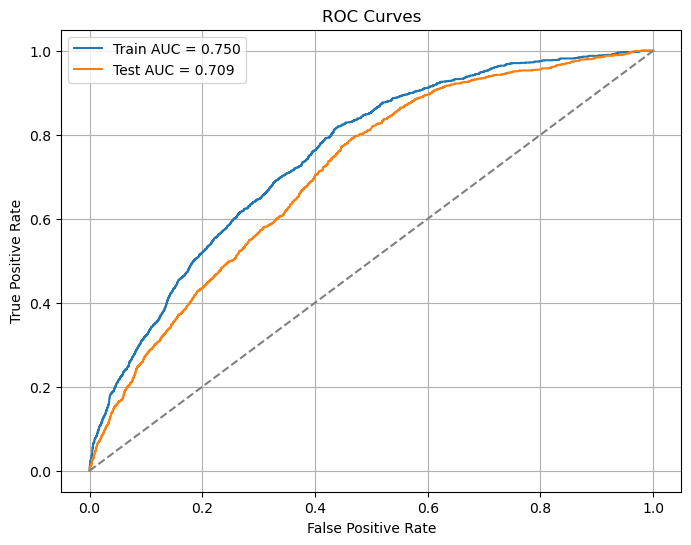

{'n_estimators': 400, 'min_samples_split': 50, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 100, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.6s
[CV] END bootstrap=True, class_weight=balanced, max_depth=250, max_features=None, min_samples_leaf=700, min_samples_split=100, n_estimators=500; total time=   7.7s
[CV] END bootstrap=True, class_weight=balanced, max_depth=200, max_features=None, min_samples_leaf=700, min_samples_split=15

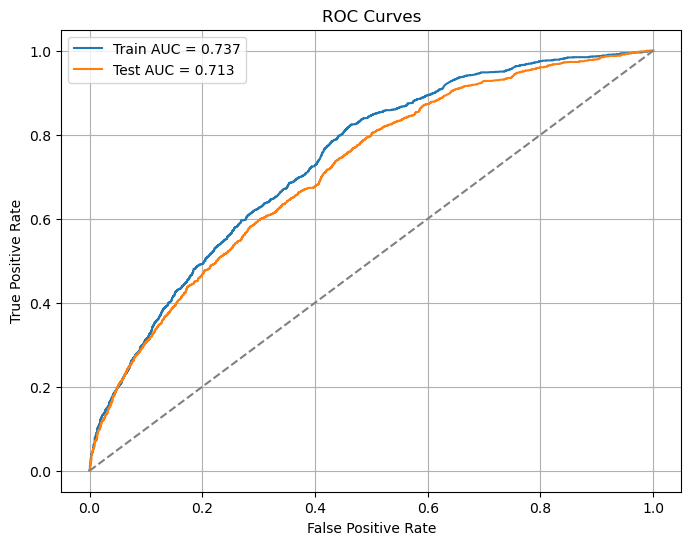

{'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 600, 'max_features': None, 'max_depth': 250, 'class_weight': 'balanced', 'bootstrap': True}

Average AUC over 10 runs:
Train AUC: Mean = 0.7366, Std = 0.0060
Test AUC:  Mean = 0.7164, Std = 0.0105
Train F1: Mean = 0.3749, Std = 0.0082
Test F1:  Mean = 0.3649, Std = 0.0138


In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold


# splitting galaxies into test/train based on subID
unique_galaxies = np.unique(low_mass_central_df['subID'])

train_aucs = []
test_aucs = []
feature_importances_list = []
feature_names = None
train_f1s = []
test_f1s = []


for seed in range(10):
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    train_data = low_mass_central_df[low_mass_central_df['subID'].isin(train_galaxies)]
    test_data = low_mass_central_df[low_mass_central_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['quenching_vector', 'subID']), train_data['quenching_vector']
    X_test, y_test = test_data.drop(columns=['quenching_vector', 'subID']), test_data['quenching_vector']

    if feature_names is None:
        feature_names = X_train.columns.tolist()
    # scaling
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    param_grid = {
    'n_estimators': [300, 400, 500],  
    'max_depth': [50, 100, 150, 200, 250],  
     'min_samples_split': [50, 100, 150],  
    'min_samples_leaf': [600, 700],
#     'max_features': ['sqrt', 'log2'],  
    'max_features': [None],  
    'bootstrap': [True],
    'class_weight':['balanced']
    }
    rf = RandomForestClassifier(random_state=seed)
    groups_train = train_data['subID']
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)

    random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=cv, 
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=2)

    random_search.fit(X_train_scaled, y_train, groups=groups_train)

    best_rf = random_search.best_estimator_

    y_train_prob = best_rf.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    # ROC curves
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}')
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(random_search.best_params_)

    
    # aucs and feature importance
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    feature_importances_list.append(best_rf.feature_importances_)
    
    train_aucs.append(train_auc)
    test_aucs.append(test_auc)


    y_train_pred = best_rf.predict(X_train_scaled)
    y_test_pred = best_rf.predict(X_test_scaled)

    # f1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
print("\nAverage AUC over 10 runs:")
print(f"Train AUC: Mean = {np.mean(train_aucs):.4f}, Std = {np.std(train_aucs):.4f}")
print(f"Test AUC:  Mean = {np.mean(test_aucs):.4f}, Std = {np.std(test_aucs):.4f}")
print(f"Train F1: Mean = {np.mean(train_f1s):.4f}, Std = {np.std(train_f1s):.4f}")
print(f"Test F1:  Mean = {np.mean(test_f1s):.4f}, Std = {np.std(test_f1s):.4f}")


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
6       bulge         0.355390  0.059084
1  avg_s_mass         0.295116  0.048142
0   bin_radii         0.194445  0.030739
3      BHMass         0.073967  0.072933
4       Mhalo         0.055146  0.048974
2      s_mass         0.014134  0.010920
5    overdens         0.011802  0.018655


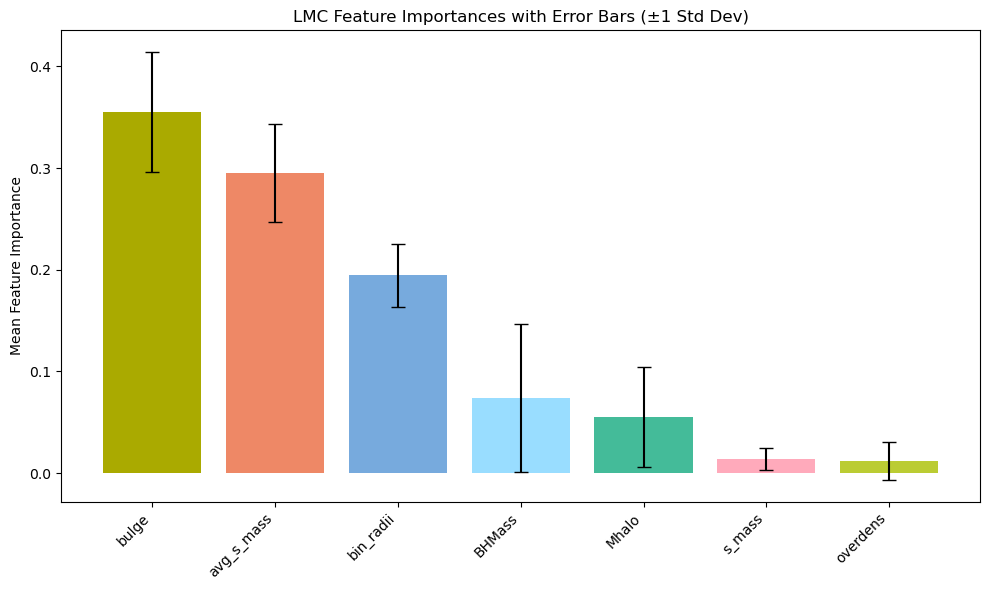

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("LMC Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [10]:
low_mass_central_df.corr()

,subID,bin_radii,avg_s_mass,quenching_vector,s_mass,BHMass,Mhalo,overdens,bulge
subID,1.000000,-0.010267,-0.217171,0.147191,-0.670885,-0.619542,-0.747887,0.016276,-0.098708
bin_radii,-0.010267,1.000000,-0.749821,-0.060734,0.008246,0.002947,0.006360,-0.001064,0.004062
avg_s_mass,-0.217171,-0.749821,1.000000,-0.114288,0.364772,0.388115,0.099861,0.035525,-0.069786
quenching_vector,0.147191,-0.060734,-0.114288,1.000000,-0.127008,-0.125578,-0.064043,0.051309,0.136096
s_mass,-0.670885,0.008246,0.364772,-0.127008,1.000000,0.900527,0.357044,0.030526,0.025907
BHMass,-0.619542,0.002947,0.388115,-0.125578,0.900527,1.000000,0.323753,0.032237,0.096778
Mhalo,-0.747887,0.006360,0.099861,-0.064043,0.357044,0.323753,1.000000,0.046091,0.080836
overdens,0.016276,-0.001064,0.035525,0.051309,0.030526,0.032237,0.046091,1.000000,0.003896
bulge,-0.098708,0.004062,-0.069786,0.136096,0.025907,0.096778,0.080836,0.003896,1.000000


In [11]:
import os
# Define your directory and file name
directory = 'rf_classification_outputs'
filename = 'lmc_rf_quenching.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to rf_classification_outputs/lmc_rf_quenching.csv


In [12]:
train_mean = round(np.mean(train_aucs), 2)
test_mean = round(np.mean(test_aucs), 2)
print(train_mean)
df = pd.DataFrame({
    'Train AUC': [train_mean],
    'Test AUC': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'rf_classification_outputs'
filename = 'lmc_rf_quenching_auc.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

0.74
   Train AUC  Test AUC
0       0.74      0.72
DataFrame saved to rf_classification_outputs/lmc_rf_quenching_auc.csv
